# Módulo 30 - Aplicação do K-Means na Base Penguins

## 1 Objetivo

O objetivo desta atividade é aplicar o algoritmo de clusterização K-Means na base de dados `penguins`, disponível no pacote Seaborn, para identificar agrupamentos entre diferentes espécies de pinguins com base em características físicas.

Para isso, serão realizadas etapas de tratamento de dados ausentes, seleção das variáveis numéricas, padronização dos dados, aplicação do algoritmo K-Means com três clusters e visualização dos agrupamentos por meio de gráficos de dispersão com centroides.

A análise busca verificar se os grupos formados pelo algoritmo apresentam relação com as espécies reais presentes na base: Adelie, Chinstrap e Gentoo.

species: Espécie do pinguim (Adelie, Chinstrap, Gentoo)

island: Ilha onde o pinguim foi observado (Biscoe, Dream, Torgersen)

bill_length_mm: Comprimento do bico em milímetros

bill_depth_mm: Profundidade do bico em milímetros

flipper_length_mm: Comprimento da barbatana em milímetros

body_mass_g: Massa corporal em gramas

sex: Sexo do pinguim (Male, Female)

year: Ano em que a observação foi feita

## 2 Carregamento de dados

In [1]:
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns

In [2]:
penguins = sns.load_dataset('penguins')

In [3]:
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


## 3 Tratamento dos dados ausentes e seleção das variáveis

In [4]:
# Verificando valores ausentes
penguins.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [5]:
# Removendo linhas com valores ausentes da base original
clean_penguins = penguins.dropna().copy()

In [6]:
# Conferindo se ainda existem valores ausentes
clean_penguins.isnull().sum()

species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

In [7]:
# Selecionando apenas as variáveis numéricas/físicas para o K-Means
standardize_columns = [
    'bill_length_mm',
    'bill_depth_mm',
    'flipper_length_mm',
    'body_mass_g'
]

penguins_kmeans = clean_penguins[standardize_columns].copy()

penguins_kmeans.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,39.1,18.7,181.0,3750.0
1,39.5,17.4,186.0,3800.0
2,40.3,18.0,195.0,3250.0
4,36.7,19.3,193.0,3450.0
5,39.3,20.6,190.0,3650.0


Após verificar os valores ausentes, as linhas com dados faltantes foram removidas. Também foram excluídas da base utilizada no K-Means as variáveis categóricas `species`, `island` e `sex`, pois o algoritmo trabalha com variáveis numéricas. Dessa forma, foram mantidas apenas as variáveis físicas dos pinguins.

## 4 - Visualização e análise descritiva dos dados

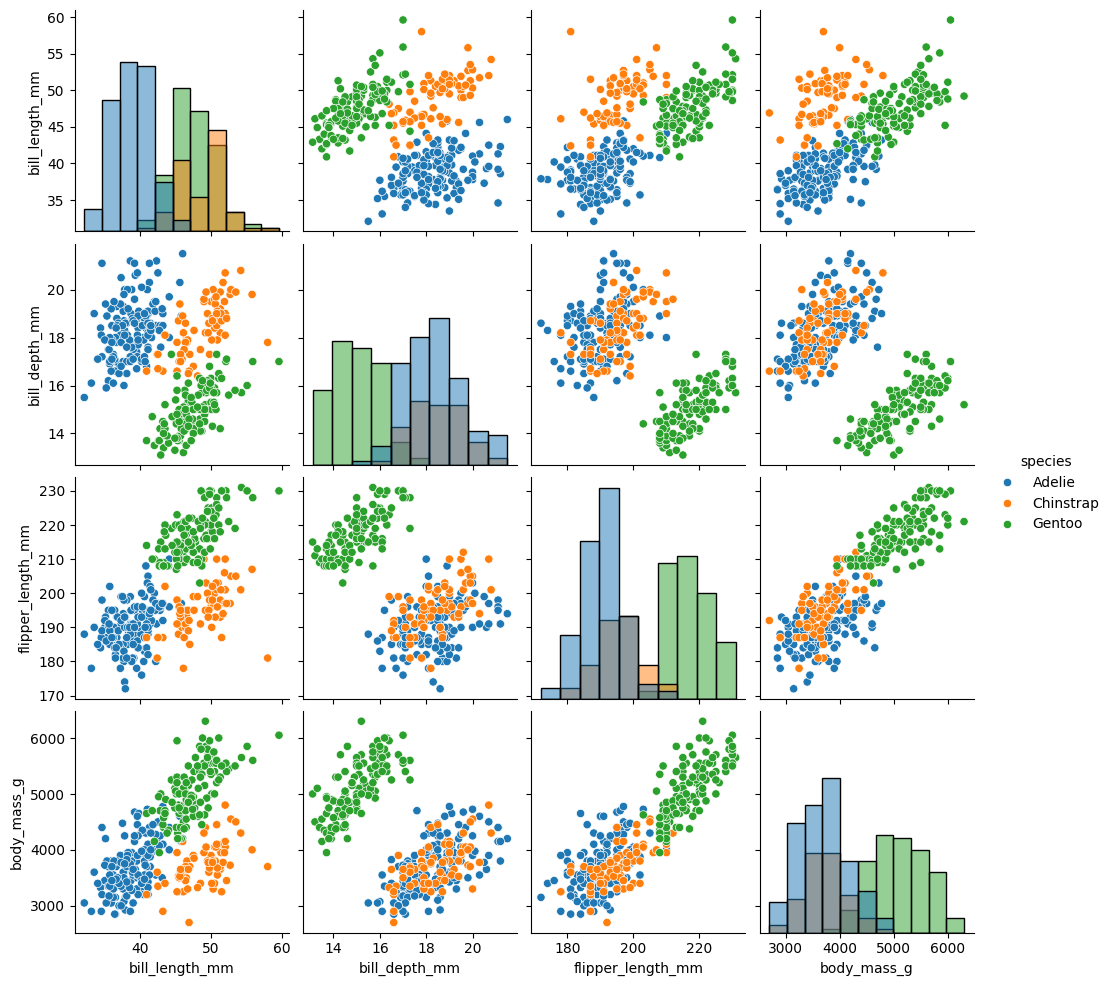

In [29]:
sns.pairplot(
    clean_penguins,
    vars=standardize_columns,
    hue='species',
    diag_kind='hist'
)

A partir da análise visual com o pairplot, é possível identificar possíveis agrupamentos entre os pinguins.

A espécie Gentoo apresenta uma separação mais evidente em relação às demais, principalmente nas variáveis `flipper_length_mm` e `body_mass_g`, pois possui maior comprimento da nadadeira e maior massa corporal.

As espécies Adelie e Chinstrap apresentam maior sobreposição em algumas combinações de variáveis, especialmente nas medidas relacionadas ao bico.

Assim, é possível identificar aproximadamente três agrupamentos, o que está de acordo com as três espécies presentes na base: Adelie, Chinstrap e Gentoo.

## 5 Padronização e visualização dos dados

In [9]:
standardize_penguins = penguins_kmeans.copy()

In [10]:
# Inicializar o StandardScaler
scaler = StandardScaler()

# Ajustar e transformar os dados selecionados
standardize_penguins[standardize_columns] = scaler.fit_transform(penguins_kmeans[standardize_columns])

In [11]:
standardize_penguins.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,-0.896042,0.780732,-1.426752,-0.568475
1,-0.822788,0.119584,-1.069474,-0.506286
2,-0.676280,0.424729,-0.426373,-1.190361
4,-1.335566,1.085877,-0.569284,-0.941606
5,-0.859415,1.747026,-0.783651,-0.692852


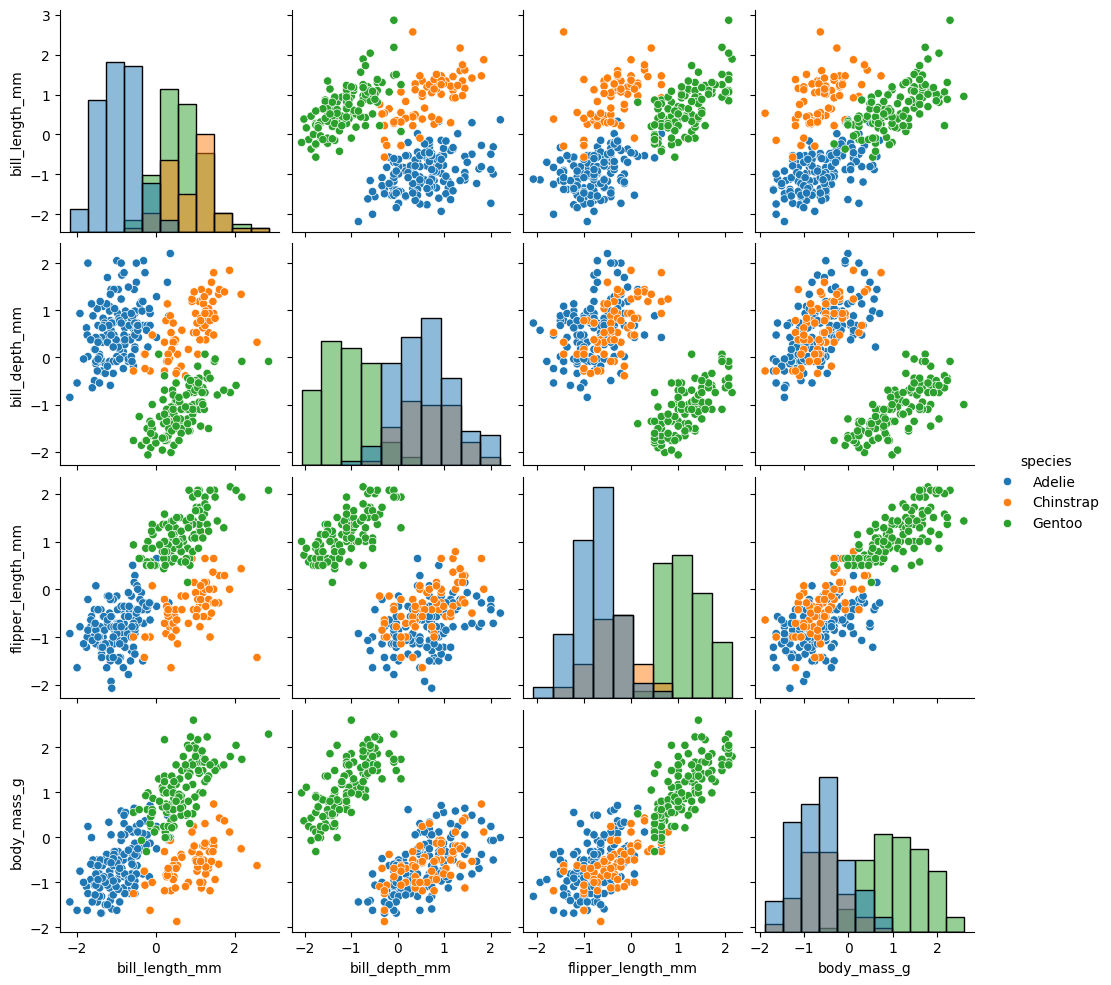

In [30]:
standardize_penguins_plot = standardize_penguins.copy()
standardize_penguins_plot['species'] = clean_penguins['species']

sns.pairplot(
    standardize_penguins_plot,
    vars=standardize_columns,
    hue='species',
    diag_kind='hist'
)

A padronização foi realizada para colocar todas as variáveis na mesma escala. Esse processo é importante porque o K-Means utiliza distâncias para formar os clusters. Como a variável `body_mass_g` possui valores muito maiores que as demais, ela poderia influenciar mais o agrupamento se os dados não fossem padronizados.

## 6 Aplicação do algoritmo K-Means

In [13]:
# Rodar o algoritmo K-Means com 3 clusters
kmeans_pinguins_3 = KMeans(n_clusters=3, n_init=10, random_state=42)

kmeans_pinguins_3.fit(standardize_penguins)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [14]:
# Centroides padronizados retornados pelo K-Means
centroides_padronizados_3 = kmeans_pinguins_3.cluster_centers_

centroides_padronizados_3

array([[-1.04680889,  0.48662566, -0.88169491, -0.7627539 ],
       [ 0.65475809, -1.10270671,  1.16246305,  1.10121078],
       [ 0.67202511,  0.80526339, -0.28934658, -0.38410387]])

In [15]:
# Inverter a padronização para obter os centroides na escala original
centroides_originais_3 = scaler.inverse_transform(centroides_padronizados_3)

centroides_originais_3

array([[  38.27674419,   18.12170543,  188.62790698, 3593.79844961],
       [  47.56806723,   14.99663866,  217.23529412, 5092.43697479],
       [  47.66235294,   18.74823529,  196.91764706, 3898.23529412]])

In [16]:
# Criando um DataFrame com os centroides originais
df_centroides_3 = pd.DataFrame(
    centroides_originais_3,
    columns=standardize_columns
)

df_centroides_3['cluster'] = df_centroides_3.index.astype(str)

df_centroides_3

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,cluster
0,38.276744,18.121705,188.627907,3593.798450,0
1,47.568067,14.996639,217.235294,5092.436975,1
2,47.662353,18.748235,196.917647,3898.235294,2


In [17]:
# Criando os labels dos clusters
labels_3 = kmeans_pinguins_3.labels_

labels_3

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 2,
       0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0,
       0, 2, 0, 2, 0, 0, 0, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0,
       0, 2, 0, 0, 0, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 2, 2, 2, 2,
       0, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [18]:
# Adicionando os clusters na base original limpa
clean_penguins['cluster'] = labels_3.astype(str)

clean_penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,cluster
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male,0
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female,0
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female,0
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female,0
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male,0


In [19]:
# Verificando a quantidade de registros por cluster
clean_penguins['cluster'].value_counts().sort_index()

cluster
0    129
1    119
2     85
Name: count, dtype: int64

In [20]:
# Comparando espécies reais com os clusters encontrados
pd.crosstab(clean_penguins['species'], clean_penguins['cluster'])

cluster,0,1,2
species,,,
Adelie,124,0,22
Chinstrap,5,0,63
Gentoo,0,119,0


O algoritmo K-Means foi aplicado com `n_clusters=3`, pois a base possui três espécies de pinguins: Adelie, Chinstrap e Gentoo. Após o treinamento, cada pinguim recebeu um rótulo de cluster.

A comparação entre as espécies reais e os clusters encontrados mostra que o algoritmo consegue separar melhor a espécie Gentoo, que apresenta características físicas mais distintas. Já as espécies Adelie e Chinstrap apresentam maior sobreposição em algumas variáveis.

## 7 Construção dos gráficos de dispersão com centroides

In [24]:
# Criando um dataframe com os dados originais e os rótulos de cluster
df_clusters = clean_penguins[
    [
        'bill_length_mm',
        'bill_depth_mm',
        'flipper_length_mm',
        'body_mass_g',
        'species',
        'cluster'
    ]
].copy()

# Garantindo que cluster seja tratado como categoria/texto no gráfico
df_clusters['cluster'] = df_clusters['cluster'].astype(str)

df_clusters.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,species,cluster
0,39.1,18.7,181.0,3750.0,Adelie,0
1,39.5,17.4,186.0,3800.0,Adelie,0
2,40.3,18.0,195.0,3250.0,Adelie,0
4,36.7,19.3,193.0,3450.0,Adelie,0
5,39.3,20.6,190.0,3650.0,Adelie,0


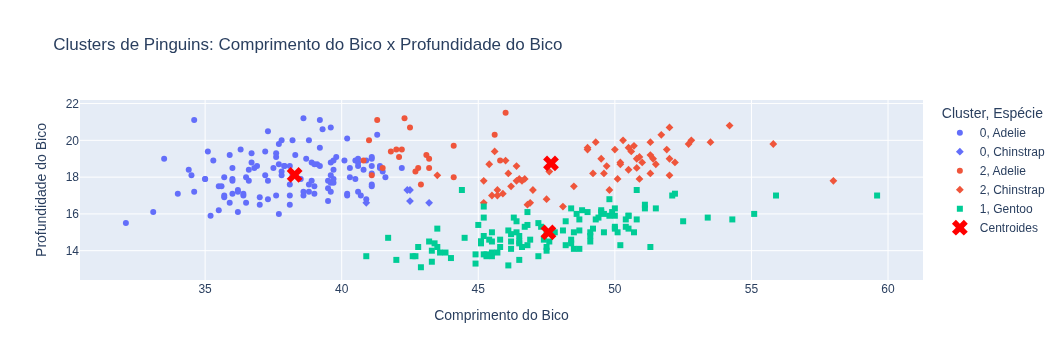

In [25]:
# Plotar os pontos dos dados coloridos pelo cluster
fig = px.scatter(
    df_clusters,
    x='bill_length_mm',
    y='bill_depth_mm',
    color='cluster',
    symbol='species',
    title='Clusters de Pinguins: Comprimento do Bico x Profundidade do Bico',
    labels={
        'bill_length_mm': 'Comprimento do Bico',
        'bill_depth_mm': 'Profundidade do Bico',
        'cluster': 'Cluster',
        'species': 'Espécie'
    }
)

# Adicionar os centroides ao gráfico
fig.add_scatter(
    x=df_centroides_3['bill_length_mm'],
    y=df_centroides_3['bill_depth_mm'],
    mode='markers',
    marker=dict(color='red', symbol='x', size=14),
    name='Centroides'
)

fig.show()

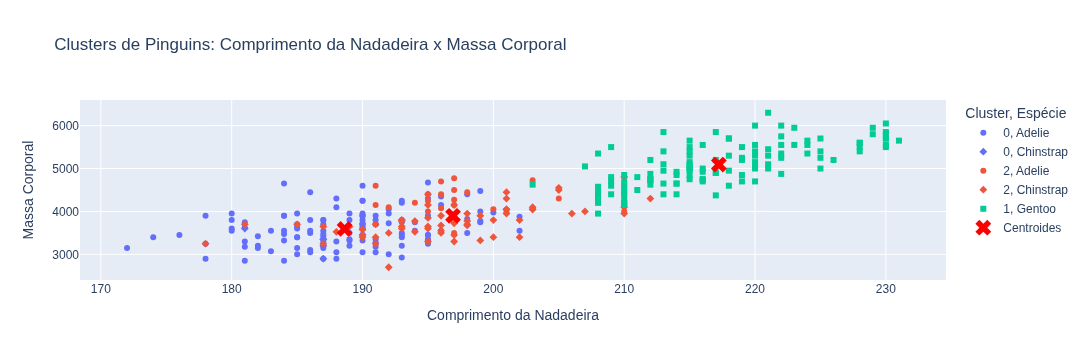

In [26]:
# Plotar os pontos dos dados coloridos pelo cluster
fig = px.scatter(
    df_clusters,
    x='flipper_length_mm',
    y='body_mass_g',
    color='cluster',
    symbol='species',
    title='Clusters de Pinguins: Comprimento da Nadadeira x Massa Corporal',
    labels={
        'flipper_length_mm': 'Comprimento da Nadadeira',
        'body_mass_g': 'Massa Corporal',
        'cluster': 'Cluster',
        'species': 'Espécie'
    }
)

# Adicionar os centroides ao gráfico
fig.add_scatter(
    x=df_centroides_3['flipper_length_mm'],
    y=df_centroides_3['body_mass_g'],
    mode='markers',
    marker=dict(color='red', symbol='x', size=14),
    name='Centroides'
)

fig.show()

In [27]:
averages_by_cluster = clean_penguins.groupby('cluster')[standardize_columns].mean()

averages_by_cluster

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
cluster,,,,
0,38.276744,18.121705,188.627907,3593.798450
1,47.568067,14.996639,217.235294,5092.436975
2,47.662353,18.748235,196.917647,3898.235294


No primeiro gráfico, utilizando `bill_length_mm` e `bill_depth_mm`, é possível observar uma separação parcial entre os clusters. Porém, existe sobreposição entre algumas espécies, principalmente Adelie e Chinstrap.

No segundo gráfico, utilizando `flipper_length_mm` e `body_mass_g`, a separação dos grupos fica mais evidente. A espécie Gentoo se destaca por apresentar maior comprimento da nadadeira e maior massa corporal, formando um grupo mais separado.

Os centroides representam os pontos médios de cada cluster e ajudam a visualizar a posição central dos agrupamentos encontrados pelo K-Means.

## 8 Aplicações de algoritmos de clusterização

Algumas aplicações de algoritmos de clusterização são:

1. Segmentação de clientes: empresas podem agrupar clientes com comportamentos de compra semelhantes, permitindo criar campanhas de marketing mais direcionadas.

2. Agrupamento de dados biológicos: algoritmos de clusterização podem ser usados para agrupar espécies, pacientes ou amostras com características semelhantes, auxiliando em análises científicas e médicas.

3. Organização de documentos, imagens ou produtos: a clusterização pode ser usada para agrupar conteúdos semelhantes, facilitando sistemas de recomendação, buscas e classificação automática.

# 9 Conclusão

Nesta atividade, foi aplicado o algoritmo K-Means para agrupar pinguins com base em características físicas. Inicialmente, foram tratados os valores ausentes e selecionadas apenas as variáveis numéricas relevantes para o modelo. Em seguida, os dados foram padronizados para evitar que variáveis com escalas maiores influenciassem o cálculo das distâncias.

Com `k=3`, o algoritmo identificou três agrupamentos, coerentes com a existência de três espécies na base. A análise visual e a comparação com as espécies reais mostraram que a espécie Gentoo foi separada com mais facilidade, enquanto Adelie e Chinstrap apresentaram maior sobreposição em algumas variáveis.